# 🎯 04 — Tournament Simulation (World Cup 2026)
## FIFA World Cup 2026 Prediction Project

Notebook ini mensimulasikan turnamen WC 2026:
- Menggunakan model ensemble dari notebook 03
- Monte Carlo simulation (10.000 iterasi)
- Prediksi fase grup + knockout
- Probabilitas juara per tim

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from src.elo import EloRatingSystem
from src.features import normalize_team_name, normalize_team_names_in_df, TEAM_NAME_MAP
from src.simulation import WorldCup2026Simulator

plt.style.use('seaborn-v0_8-darkgrid')
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')

## 1. Load Models & Data

In [2]:
# Load WC 2026 groups
wc2026_groups = pd.read_csv(DATA_DIR / '2026_world_cup_groups.csv')
wc2026_groups = normalize_team_names_in_df(wc2026_groups, ['Team'])

print(f'WC 2026: {len(wc2026_groups)} teams in {wc2026_groups["Group"].nunique()} groups')
print()
for group, gdf in wc2026_groups.groupby('Group'):
    teams = ', '.join([f"{r['Team']} (#{r['FIFA Ranking']})" for _, r in gdf.iterrows()])
    print(f'  Group {group}: {teams}')

WC 2026: 48 teams in 12 groups

  Group A: Mexico (#15), South Africa (#60), South Korea (#25), Czech Republic (#41)
  Group B: Canada (#30), Bosnia and Herzegovina (#65), Qatar (#55), Switzerland (#19)
  Group C: Brazil (#6), Morocco (#8), Haiti (#83), Scotland (#43)
  Group D: United States (#16), Paraguay (#40), Australia (#27), Turkey (#22)
  Group E: Germany (#10), Curaçao (#82), Ivory Coast (#34), Ecuador (#23)
  Group F: Netherlands (#7), Japan (#18), Sweden (#38), Tunisia (#44)
  Group G: Belgium (#9), Egypt (#29), Iran (#21), New Zealand (#85)
  Group H: Spain (#2), Cape Verde (#69), Saudi Arabia (#61), Uruguay (#17)
  Group I: France (#1), Senegal (#14), Iraq (#57), Norway (#31)
  Group J: Argentina (#3), Algeria (#28), Austria (#24), Jordan (#63)
  Group K: Portugal (#5), DR Congo (#46), Uzbekistan (#50), Colombia (#13)
  Group L: England (#4), Croatia (#11), Ghana (#74), Panama (#33)


In [3]:
# Rebuild Elo ratings
intl = pd.read_csv(DATA_DIR / 'international_matches.csv')
intl['Date'] = pd.to_datetime(intl['Date'])
intl = intl.sort_values('Date').reset_index(drop=True)
intl = normalize_team_names_in_df(intl, ['Home Team', 'Away Team'])

elo = EloRatingSystem(initial_elo=1500)
print('Rebuilding Elo ratings...')
intl_with_elo = elo.process_matches(
    intl,
    home_col='Home Team', away_col='Away Team',
    home_goals_col='Home Goals', away_goals_col='Away Goals',
    tournament_col='Tournament', date_col='Date',
    verbose=True
)

Rebuilding Elo ratings...


Processed 49450 matches for 336 teams
Top 5 teams: [('Spain', 2261.9), ('Argentina', 2179.3), ('France', 2165.1), ('England', 2153.6), ('Germany', 2087.8)]


In [4]:
# Elo ratings for WC 2026 teams
print('\nElo Ratings for WC 2026 Teams:')
print('=' * 45)
wc_elos = []
for _, row in wc2026_groups.iterrows():
    team = row['Team']
    elo_rating = elo.get_rating(team)
    wc_elos.append({'Team': team, 'Group': row['Group'], 
                    'FIFA_Ranking': row['FIFA Ranking'], 'Elo': round(elo_rating, 1)})

wc_elos_df = pd.DataFrame(wc_elos).sort_values('Elo', ascending=False)
for i, (_, r) in enumerate(wc_elos_df.head(20).iterrows()):
    print(f'  {i+1:2d}. {r["Team"]:20s} Group {r["Group"]}  FIFA #{r["FIFA_Ranking"]:2.0f}  Elo: {r["Elo"]:.0f}')


Elo Ratings for WC 2026 Teams:
   1. Spain                Group H  FIFA # 2  Elo: 2262
   2. Argentina            Group J  FIFA # 3  Elo: 2179
   3. France               Group I  FIFA # 1  Elo: 2165
   4. England              Group L  FIFA # 4  Elo: 2154
   5. Germany              Group E  FIFA #10  Elo: 2088
   6. Brazil               Group C  FIFA # 6  Elo: 2069
   7. Colombia             Group K  FIFA #13  Elo: 2068
   8. Ecuador              Group E  FIFA #23  Elo: 2065
   9. Norway               Group I  FIFA #31  Elo: 2062
  10. Netherlands          Group F  FIFA # 7  Elo: 2062
  11. Morocco              Group C  FIFA # 8  Elo: 2056
  12. Japan                Group F  FIFA #18  Elo: 2056
  13. Portugal             Group K  FIFA # 5  Elo: 2055
  14. Turkey               Group D  FIFA #22  Elo: 2030
  15. Croatia              Group L  FIFA #11  Elo: 2016
  16. Switzerland          Group B  FIFA #19  Elo: 2004
  17. Belgium              Group G  FIFA # 9  Elo: 1993
  18. Mexico    

## 2. Setup Prediction Function

In [5]:
# Prediction function based on Elo ratings
def predict_match_elo(team_a, team_b):
    """
    Prediksi pertandingan berdasarkan Elo rating.
    Mengembalikan probabilitas menang/seri/kalah.
    """
    result = elo.predict_match(team_a, team_b)
    
    return {
        'home_win': result[f'{team_a}_win'],
        'draw': result['draw'],
        'away_win': result[f'{team_b}_win'],
    }

# Test
test_result = predict_match_elo('Brazil', 'Germany')
print(f'Test: Brazil vs Germany → {test_result}')
test_result = predict_match_elo('France', 'Argentina')
print(f'Test: France vs Argentina → {test_result}')

Test: Brazil vs Germany → {'home_win': np.float64(0.3585), 'draw': np.float64(0.2423), 'away_win': np.float64(0.3992)}
Test: France vs Argentina → {'home_win': np.float64(0.3625), 'draw': np.float64(0.2442), 'away_win': np.float64(0.3934)}


## 3. Single Simulation (Detailed)

In [6]:
# Run one detailed simulation
sim = WorldCup2026Simulator(wc2026_groups, predict_fn=predict_match_elo, seed=42)

# Group stage
print('🏟️  Simulating Group Stage...')
print('=' * 60)
standings = sim.simulate_group_stage()

for group_name in sorted(standings.keys()):
    df = standings[group_name]
    print(f'\nGroup {group_name}:')
    print(df[['Team', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']].to_string(index=False))

🏟️  Simulating Group Stage...

Group A:
          Team  MP  W  D  L  GF  GA  GD  Pts
   South Korea   3  2  1  0   5   1   4    7
        Mexico   3  2  1  0   3   1   2    7
Czech Republic   3  1  0  2   3   2   1    3
  South Africa   3  0  0  3   0   7  -7    0

Group B:
                  Team  MP  W  D  L  GF  GA  GD  Pts
                Canada   3  2  1  0   4   1   3    7
           Switzerland   3  1  2  0   2   1   1    5
                 Qatar   3  1  1  1   1   1   0    4
Bosnia and Herzegovina   3  0  0  3   0   4  -4    0

Group C:
    Team  MP  W  D  L  GF  GA  GD  Pts
 Morocco   3  2  1  0   4   1   3    7
  Brazil   3  2  0  1   2   1   1    6
Scotland   3  1  1  1   3   2   1    4
   Haiti   3  0  0  3   0   5  -5    0

Group D:
         Team  MP  W  D  L  GF  GA  GD  Pts
       Turkey   3  2  0  1   3   1   2    6
     Paraguay   3  2  0  1   5   4   1    6
United States   3  1  0  2   4   5  -1    3
    Australia   3  1  0  2   2   4  -2    3

Group E:
       Team  MP

In [7]:
# Qualified teams
qualified = sim.get_qualified_teams(standings)

print('\n✅ Qualified for Round of 32:')
print(f'  Group winners (12):   {", ".join(qualified["first"])}')
print(f'  Group runners-up (12): {", ".join(qualified["second"])}')
print(f'  Best 3rd place (8):   {", ".join(qualified["third"])}')
print(f'  Total: {len(qualified["first"]) + len(qualified["second"]) + len(qualified["third"])} teams')


✅ Qualified for Round of 32:
  Group winners (12):   South Korea, Canada, Morocco, Turkey, Ecuador, Japan, Belgium, Spain, France, Argentina, Colombia, England
  Group runners-up (12): Mexico, Switzerland, Brazil, Paraguay, Germany, Netherlands, Egypt, Cape Verde, Senegal, Austria, Portugal, Ghana
  Best 3rd place (8):   Uruguay, Scotland, New Zealand, Croatia, Sweden, Qatar, Iraq, Czech Republic
  Total: 32 teams


In [8]:
# Knockout stage
print('\n⚔️  Simulating Knockout Stage...')
print('=' * 60)
results = sim.simulate_knockout(qualified, standings)

for stage in ['round_of_32', 'round_of_16', 'quarter_finals', 'semi_finals']:
    matches = results[stage]
    print(f'\n{stage.replace("_", " ").title()}:')
    for m in matches:
        winner_mark = '🏆' if m['winner'] == m['team_a'] else '  '
        loser_mark = '🏆' if m['winner'] == m['team_b'] else '  '
        print(f'  {winner_mark} {m["team_a"]:20s} {m["score"]:5s} {m["team_b"]:20s} {loser_mark}')

print(f'\n🥉 Third Place: {results["third_place"]}')
print(f'\n🏆🏆🏆 FINAL: {results["final"]}')
print(f'\n🎉 CHAMPION: {results["champion"]}!')


⚔️  Simulating Knockout Stage...

Round Of 32:
     South Korea          0-1   Brazil               🏆
     Canada               0-1   Paraguay             🏆
     Morocco              1-3   Germany              🏆
  🏆 Turkey               3-0   Netherlands            
  🏆 Ecuador              3-1   Egypt                  
  🏆 Japan                3-1   Cape Verde             
  🏆 Belgium              2-0   Senegal                
  🏆 Spain                1-0   Austria                
     France               1-2   Portugal             🏆
  🏆 Argentina            2-0   Ghana                  
  🏆 Colombia             3-0   Mexico                 
  🏆 England              2-0   Switzerland            
     Uruguay              0-1   Scotland             🏆
     New Zealand          0-1   Croatia              🏆
  🏆 Sweden               1-0   Qatar                  
     Iraq                 0-1   Czech Republic       🏆

Round Of 16:
     Brazil               0-2   Paraguay             🏆
  🏆

## 4. Monte Carlo Simulation (10,000 iterations)

In [9]:
# Run Monte Carlo simulation
print('🎲 Running Monte Carlo Simulation (10,000 iterations)...')
print('   This may take a few minutes...\n')

mc_sim = WorldCup2026Simulator(wc2026_groups, predict_fn=predict_match_elo, seed=2026)
mc_results = mc_sim.run_simulation(n_simulations=10000, verbose=True)

🎲 Running Monte Carlo Simulation (10,000 iterations)...
   This may take a few minutes...



  Simulation 1000/10000...


  Simulation 2000/10000...


  Simulation 3000/10000...


  Simulation 4000/10000...


...

  Simulation 6000/10000...


  Simulation 7000/10000...


  Simulation 8000/10000...


  Simulation 9000/10000...


  Simulation 10000/10000...

Top 10 Most Likely Champions:
  Spain                 27.5%
  Argentina             11.2%
  England               10.4%
  France                 9.5%
  Germany                4.7%
  Brazil                 3.8%
  Ecuador                3.4%
  Netherlands            3.2%
  Morocco                3.1%
  Colombia               3.0%


In [10]:
# Display full results table
print('\n📊 Full Simulation Results:')
print('=' * 100)

display_cols = ['Team', 'p_champion', 'p_runner_up', 'p_semi_finals', 
                'p_quarter_finals', 'p_round_of_16', 'p_round_of_32', 
                'p_group_stage_exit']
display_df = mc_results[display_cols].copy()

# Format as percentages
for col in display_cols[1:]:
    display_df[col] = (display_df[col] * 100).round(1).astype(str) + '%'

display_df.columns = ['Team', 'Champion', 'Runner-Up', 'Semi-Finals', 
                       'QF', 'R16', 'R32', 'Group Exit']
print(display_df.to_string(index=False))


📊 Full Simulation Results:
                  Team Champion Runner-Up Semi-Finals    QF   R16   R32 Group Exit
                 Spain    27.4%     11.8%       39.3% 50.1% 64.2% 99.3%       0.7%
             Argentina    11.2%      8.6%       19.8% 28.0% 42.9% 96.0%       4.0%
               England    10.4%      9.2%       19.6% 28.6% 47.9% 96.5%       3.5%
                France     9.5%      7.4%       16.9% 25.4% 39.7% 92.8%       7.2%
               Germany     4.7%      4.9%        9.6% 19.3% 37.7% 93.8%       6.2%
                Brazil     3.8%      4.8%        8.6% 21.7% 36.4% 89.5%      10.5%
               Ecuador     3.4%      3.7%        7.0% 15.9% 32.1% 92.0%       8.0%
           Netherlands     3.2%      3.7%        6.8% 15.8% 32.2% 91.1%       8.9%
               Morocco     3.1%      4.0%        7.0% 18.9% 34.0% 89.1%      10.9%
              Colombia     3.0%      4.5%        7.6% 14.0% 28.6% 87.9%      12.1%
                 Japan     3.0%      3.8%        6.7% 14.9%

In [11]:
# Save results
mc_results.to_csv(OUTPUT_DIR / 'predictions' / 'wc2026_simulation_results.csv', index=False)
print('Results saved to outputs/predictions/wc2026_simulation_results.csv')

Results saved to outputs/predictions/wc2026_simulation_results.csv


## 5. Quick Visualization

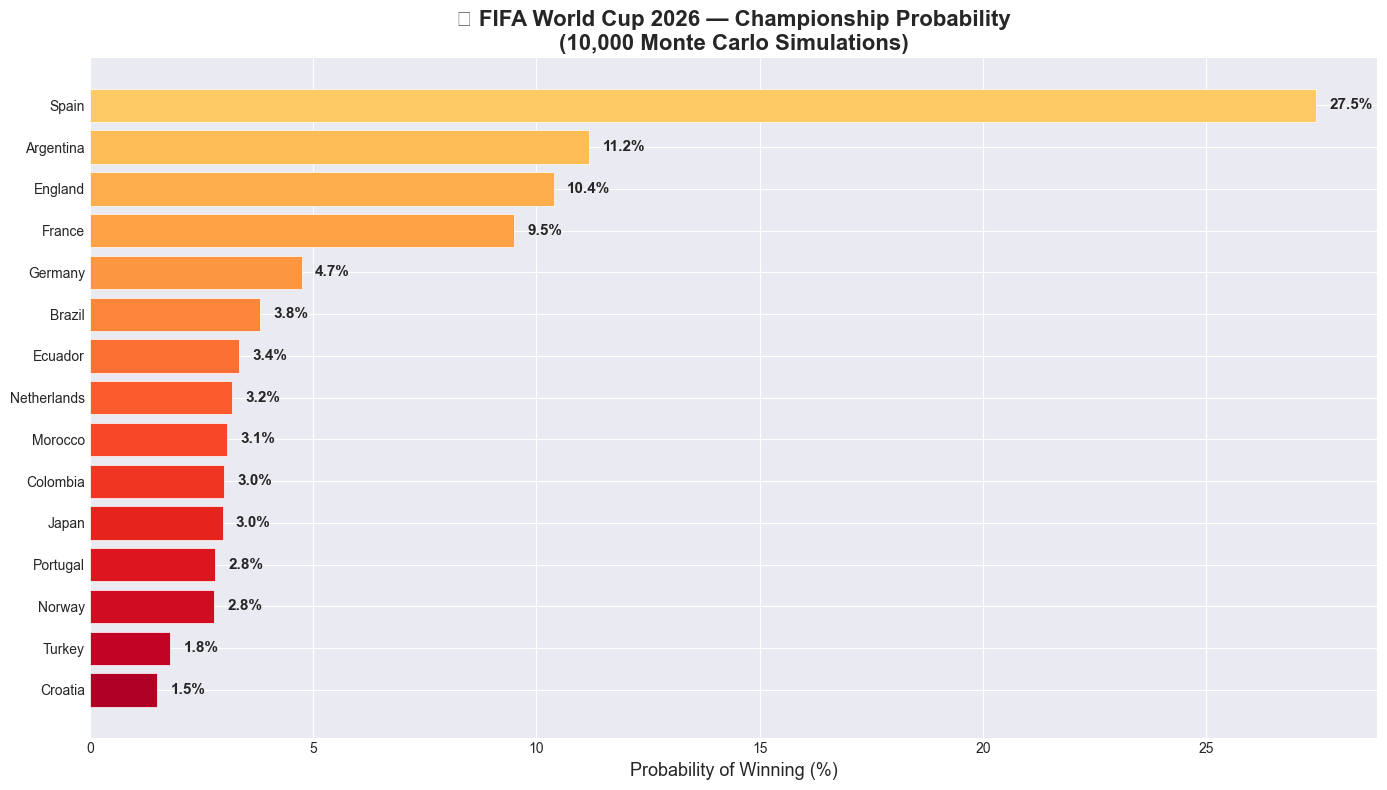


✅ Simulation complete! Next: 05_visualization.ipynb


In [12]:
# Top 15 teams by champion probability
top15 = mc_results.head(15)

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top15)))

bars = ax.barh(top15['Team'].iloc[::-1], top15['p_champion'].iloc[::-1] * 100, 
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top15['p_champion'].iloc[::-1] * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Probability of Winning (%)', fontsize=13)
ax.set_title('🏆 FIFA World Cup 2026 — Championship Probability\n(10,000 Monte Carlo Simulations)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/04_champion_probability.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Simulation complete! Next: 05_visualization.ipynb')